# 1 — Imports & Root Detection

In [1]:
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from sklearn.metrics import (
    confusion_matrix, f1_score, precision_score, recall_score
)

# Notebook‑safe project root detection
root = Path.cwd()
while not (root / "Pipeline_").exists() and root != root.parent:
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print("Project root:", root)

# Import old 224px pipeline
from Pipeline_.preprocessor import WaRPPreprocessor
from Models.ConvNeXT import ConvNeXT

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


Project root: c:\repo\Waste-Classification
Device: cuda


# 2 — Hyperparameters (Optimal)

In [2]:
# ============================
# ConvNeXt Optimal (224px)
# Hyperparameters
# ============================

EPOCHS       = 100         # Optimal = 100 epochs
BATCH_SIZE   = 32
LR           = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.4
HEAD_DEPTH   = 2           # Optimal head depth
NUM_CLASSES  = 28

print("Epochs      :", EPOCHS)
print("Batch size  :", BATCH_SIZE)
print("LR          :", LR)
print("Dropout     :", DROPOUT)
print("Head depth  :", HEAD_DEPTH)
print("Num classes :", NUM_CLASSES)


Epochs      : 100
Batch size  : 32
LR          : 0.0001
Dropout     : 0.4
Head depth  : 2
Num classes : 28


# 3 — Data Pipeline (Old 224px Preprocessor)
ConvNeXt in the old preprocessor uses:
strong transformer augmentation
minority augmentation
MixUp ON
WeightedRandomSampler

In [3]:
pp = WaRPPreprocessor(
    raw_root       = root / "Dataset/raw/Warp-C",
    processed_root = root / "Dataset/processed",
    stats_file     = root / "Dataset/dataset_stats.json",
    batch_size     = BATCH_SIZE,
    num_workers    = 4,
)

train_loader, test_loader = pp.get_loaders(model_type="convnext")

CLASS_NAMES = sorted(
    d.name for d in (root / "Dataset/processed/train").iterdir() if d.is_dir()
)

print(f"Classes       : {len(CLASS_NAMES)}")
print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")


[get_loaders] model='convnext'
  sampler=True  minority_aug=True  mixup=True  pipeline='transformer'
  train=273 batches  test=49 batches  sampler=WeightedRandom
Classes       : 28
Train batches : 273
Test  batches : 49


# 4 — Loss, Model, Optimizer, Scheduler

In [4]:
class_weights = pp.get_class_weights(device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Loss: CrossEntropyLoss + class weights")

model = ConvNeXT(
    num_classes = NUM_CLASSES,
    dropout     = DROPOUT,
    head_depth  = HEAD_DEPTH,
    freeze      = False
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY,
)

# Cosine scheduler for optimal version
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max  = EPOCHS,
    eta_min = 1e-7,
)

# Sanity check
with torch.no_grad():
    x = torch.zeros(2, 3, 224, 224).to(DEVICE)
    y = model(x)
print("Sanity output:", y.shape)


Loss: CrossEntropyLoss + class weights
Sanity output: torch.Size([2, 28])


# 5 — Training Loop (MixUp ON + Scheduler)
ConvNeXt uses MixUp in the old preprocessor.
We call the built‑in WaRPPreprocessor.mixup_batch.

In [5]:
train_losses, train_accs, test_accs = [], [], []
best_acc = 0.0

print(f"Starting {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    ep_loss = correct = total = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

        # MixUp using old preprocessor implementation
        imgs, soft_lbls = WaRPPreprocessor.mixup_batch(
            images      = imgs,
            labels      = lbls,
            num_classes = NUM_CLASSES,
            alpha       = 0.4,
        )

        optimizer.zero_grad()
        logits = model(imgs)
        log_p  = torch.nn.functional.log_softmax(logits, dim=1)
        loss   = -(soft_lbls * log_p).sum(dim=1).mean()

        loss.backward()
        optimizer.step()

        ep_loss += loss.item()
        correct += (logits.argmax(1) == lbls).sum().item()
        total   += lbls.size(0)

    scheduler.step()

    train_loss = ep_loss / len(train_loader)
    train_acc  = correct / total * 100

    # Evaluation
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
    test_acc = correct / total * 100

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), root / "Models/weights/convnext_optimal_224.pth")
        flag = " ← best"
    else:
        flag = ""

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"loss={train_loss:.4f} | train={train_acc:.2f}% | "
          f"test={test_acc:.2f}% | best={best_acc:.2f}% | "
          f"{time.time()-t0:.1f}s{flag}")


Starting 100 epochs...

Epoch   1/100 | loss=2.4233 | train=20.34% | test=62.02% | best=62.02% | 107.9s ← best
Epoch   2/100 | loss=1.6883 | train=32.86% | test=70.79% | best=70.79% | 93.1s ← best
Epoch   3/100 | loss=1.5845 | train=36.38% | test=74.60% | best=74.60% | 93.4s ← best
Epoch   4/100 | loss=1.4735 | train=37.67% | test=73.11% | best=74.60% | 92.8s
Epoch   5/100 | loss=1.3594 | train=41.43% | test=77.50% | best=77.50% | 92.9s ← best
Epoch   6/100 | loss=1.3421 | train=42.75% | test=77.95% | best=77.95% | 92.7s ← best
Epoch   7/100 | loss=1.3363 | train=43.90% | test=78.59% | best=78.59% | 92.7s ← best
Epoch   8/100 | loss=1.2557 | train=44.85% | test=79.17% | best=79.17% | 93.5s ← best
Epoch   9/100 | loss=1.2253 | train=43.13% | test=79.95% | best=79.95% | 94.4s ← best
Epoch  10/100 | loss=1.1866 | train=42.19% | test=77.05% | best=79.95% | 94.0s
Epoch  11/100 | loss=1.1323 | train=49.97% | test=77.63% | best=79.95% | 94.3s
Epoch  12/100 | loss=1.1934 | train=42.50% | test=

# 6 — Training Curves

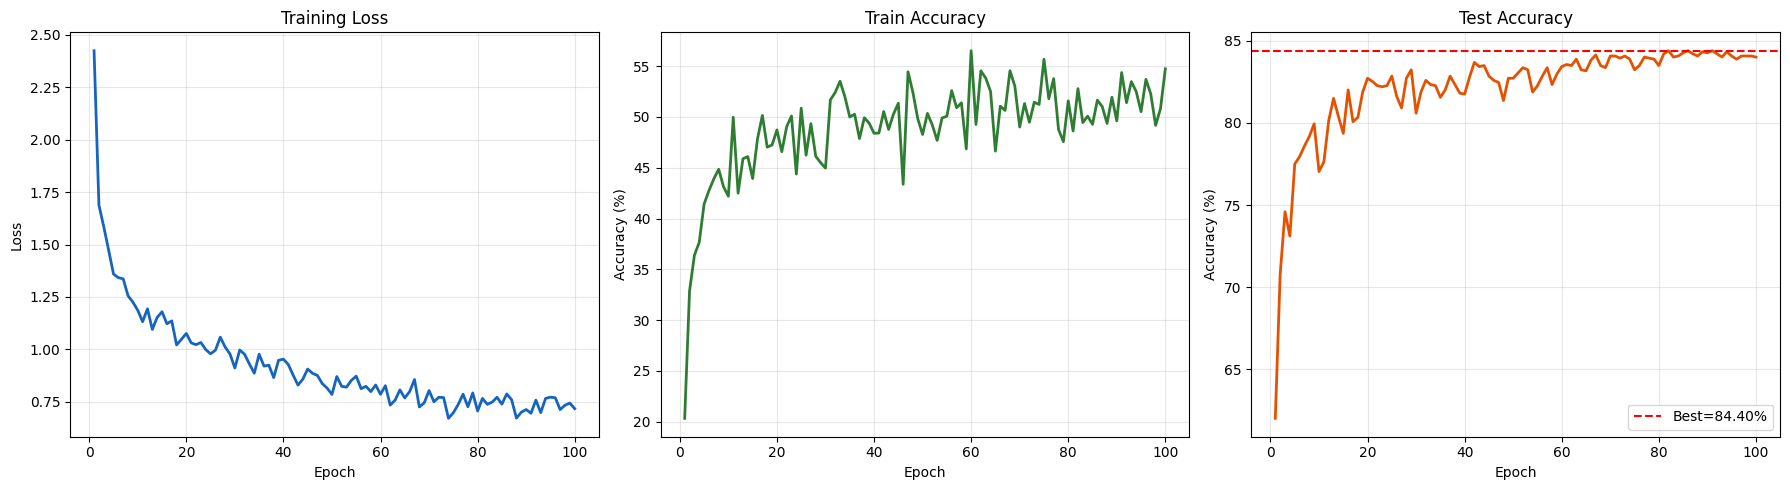

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, EPOCHS + 1)

axes[0].plot(ep, train_losses, "#1565C0", lw=2)
axes[0].set(title="Training Loss", xlabel="Epoch", ylabel="Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(ep, train_accs, "#2E7D32", lw=2)
axes[1].set(title="Train Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[1].grid(alpha=0.3)

axes[2].plot(ep, test_accs, "#E65100", lw=2)
axes[2].axhline(max(test_accs), color="red", ls="--", label=f"Best={max(test_accs):.2f}%")
axes[2].set(title="Test Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# 7 — Final Evaluation + Confusion Matrix

ConvNeXt Optimal (224px) — Final Metrics
Accuracy     : 84.40%
Macro F1     : 80.56%
Weighted F1  : 84.18%
Precision    : 82.77%
Recall       : 80.26%


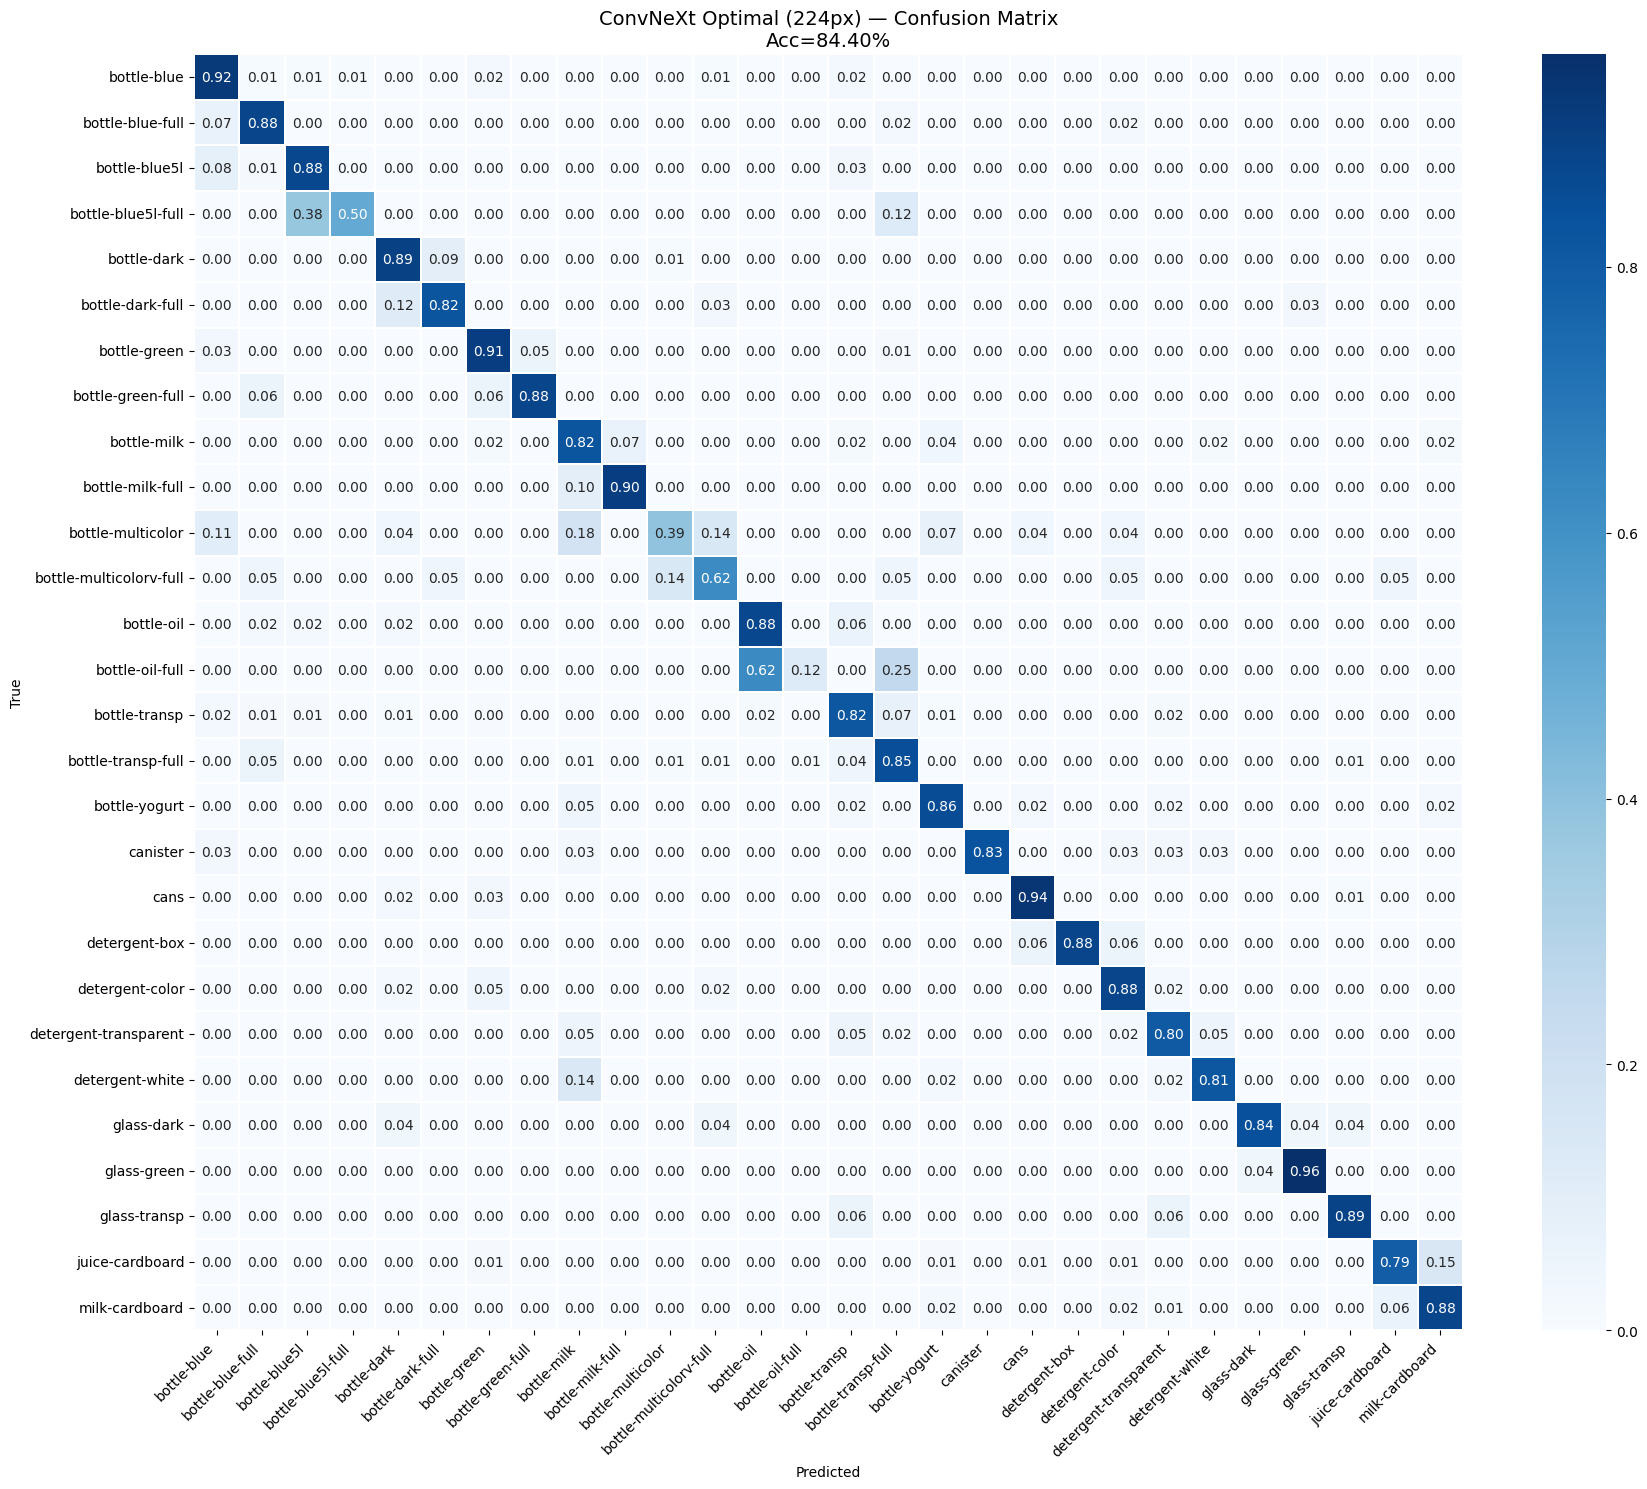

In [7]:
WEIGHTS_PATH = root / "Models/weights/convnext_optimal_224.pth"

model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(lbls.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

acc  = (y_pred == y_true).mean() * 100
macro_f1   = f1_score(y_true, y_pred, average="macro") * 100
weighted_f1 = f1_score(y_true, y_pred, average="weighted") * 100
prec = precision_score(y_true, y_pred, average="macro") * 100
rec  = recall_score(y_true, y_pred, average="macro") * 100

print("="*50)
print("ConvNeXt Optimal (224px) — Final Metrics")
print("="*50)
print(f"Accuracy     : {acc:.2f}%")
print(f"Macro F1     : {macro_f1:.2f}%")
print(f"Weighted F1  : {weighted_f1:.2f}%")
print(f"Precision    : {prec:.2f}%")
print(f"Recall       : {rec:.2f}%")
print("="*50)

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.3
)
ax.set_title(f"ConvNeXt Optimal (224px) — Confusion Matrix\nAcc={acc:.2f}%", fontsize=14)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
